In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse as scps
import scipy.sparse.linalg as ssl
import math

In [3]:
def maillage(n):
#
# Une discretisation possible d'une EDP elliptique sur le domaine ]0,1[ x ]0,1[
# Le carre [0,1]x[0,1] est maille uniquement avec des triangles; 
# Les conditions limites sont de type Dirichlet uniquement   => neumann  =[];
#
# Entrees :
# n : nombre de points par cote du care => Npts points de discretisation au
# total
#
# Sorties :
# coordinates : matrice a deux colonnes. Chaque ligne contient les 
# coordonnes 2D d'un des points de la discretisation. Ces sommets seront 
# identifies a l'indice de la ligne correspondante dans la matrice
# coordinates.
# elements3 : matrice a trois colonnes. Chaque ligne contient les indices 
# des sommets d'un element triangle, dans le sens antihoraire. 
# dirichlet : vecteur colonne des indices des sommets de la frontiere de
# Dirichlet.
# neumann : matrice a deux colonnes. Chaque ligne contient les indices 
# des deux sommets d'une arete de la frontiere de Neumann.
# (neumann est vide sur cet exemple)
#
##################################################################################
    h=1/(n-1)
    npoin       = n*n ; 
    nelem       = 2*(n-1)*(n-1) ;
    coordinates = np.zeros((npoin,2)); 
    elements3   = (np.zeros((nelem,3))).astype(int) ;
    neumann     = [];
    dirichlet=(np.zeros((4*n-4,1))).astype(int)
    # Coordonnees et connectivites :
    e = -1 ; 
    p = -1 ;
    x=np.zeros((n+1,1))
    x[n,0]=1.
    for l in range (n+1):
        x[l,0]=l*h
    for j in range (n):
            for i in range(n):
                p = p + 1  
                coordinates[p,0] = x[i,0]  
                coordinates[p,1] = x[j,0] 
                if ((i != n-1) & (j != n-1)):
                    p1 = p
                    p2 = p1 + 1 
                    p3 = p1 + n 
                    p4 = p2 + n 
                    e = e + 1 
                    elements3[e,0] = p1 
                    elements3[e,1] = p2 
                    elements3[e,2] = p3 
                    e = e + 1
                    elements3[e,0] = p4 
                    elements3[e,1] = p3 
                    elements3[e,2] = p2 
    #Liste des sommets de la frontiere de Dirichlet:
    p=-1
    for j in range(n):
        p=p+1
        dirichlet[p,0] = j  
    for j in range(n*2-1,n*(n-1),n):
        p=p+1
        dirichlet[p,0] = j 
    for j in range(n*n-1,n*n-n-1,-1):
        p=p+1
        dirichlet[p,0] = j 
    for j in range(n*n-2*n,n-1,-n):
        p=p+1
        dirichlet[p,0] = j 

    return coordinates, elements3,dirichlet, neumann

In [4]:
def show(coordinates,u):
#
# Fonction d'affichage de la solution u sur le maillage defini par
# elements3, coordinates.
#
# Entrees:
# elements3 : matrice a trois colonnes contenant les elements triangles
# de la discretisation, identifies par les indices de leurs trois
# sommets.
# coordinates : matrice a deux colonnes contenant les coordonnes 2D des
# points de la discretisation.
# u : vecteur colonne de longueur egale au nombre de lignes de
# coordinates contenant les valeurs de la solution a afficher aux
# points de la discretisation.
#
# Sorties : Aucune, mais la fonction doit s'afficher dans une figure.
##########################################################################
    ax= plt.figure().add_subplot(projection='3d')
    ax.plot_trisurf(coordinates[:,0],coordinates[:,1],u,linewidth=0.2,antialiased=True)
    plt.show()

**Partie I : maillage triangulaire et conditions de Dirichlet**

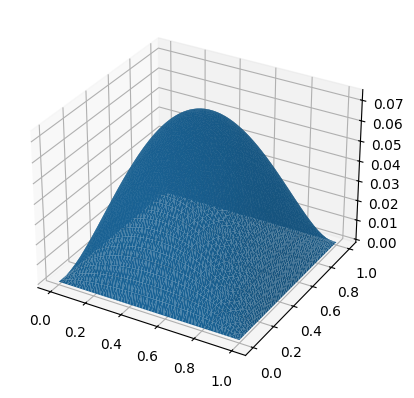

In [5]:
import numpy as np
import scipy.sparse as scps
import scipy.sparse.linalg as ssl


def f(x, y):
    return 1.0  

def u_d(x, y):
    return 0.0  

def assemblage_partie1(coordinates, elements3, dirichlet):
    n_nodes = len(coordinates)
    
    A = scps.lil_matrix((n_nodes, n_nodes))  
    b = np.zeros(n_nodes)
    
    
    for elem in elements3:
        sommets = coordinates[elem]
        x1, y1 = sommets[0]
        x2, y2 = sommets[1]
        x3, y3 = sommets[2]
        
        
        alpha = (x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1)
        aire = 0.5 * abs(alpha)
    
            
    
        b_vec = [y2 - y3, y3 - y1, y1 - y2]
        c_vec = [x3 - x2, x1 - x3, x2 - x1]
        grad = np.column_stack((b_vec, c_vec)) / alpha 
        
        
        K_local = aire * np.dot(grad, grad.T)
        
        
        xG = (x1 + x2 + x3) / 3.0
        yG = (y1 + y2 + y3) / 3.0
        b_local = (aire / 3.0) * f(xG, yG)

        for i in range(3):
            b[elem[i]] += b_local  
            for j in range(3):
                A[elem[i], elem[j]] += K_local[i, j] 
                
    for idx in dirichlet.flatten():
       
        A[idx, :] = 0.0     
        A[idx, idx] = 1.0    
        b[idx] = u_d(coordinates[idx, 0], coordinates[idx, 1])
        
    return A.tocsr(), b


coords, elems3, dirichlet_nodes, neumann_edges = maillage(60)


A, b = assemblage_partie1(coords, elems3, dirichlet_nodes)


u = ssl.spsolve(A, b)

show(coords, u)

**Partie II : maillage mixte et ajoût des conditions de Neumann**

In [6]:
############################# Maillage mixte ################
e3=np.array([[1,2,12],[2,3,12],[3,4,14],[4,5,14],[2,15,3],[3,15,4]]).astype(int)
e4=np.array([[0,1,12,11],[11,12,13,10],[12,3,14,13],[10,13,8,9],[13,14,7,8],[14,5,6,7]]).astype(int)
dds=np.array([2,15,4,6,7,8,9,10,11,0]).astype(int)
nns=np.array([[4,5],[5,6],[0,1],[1,2]]).astype(int)
ccs=np.array([[0.,0.],[0.33333333333333,0],[0.53333333333333,0.],
                      [0.66666666666667,0.33333333333333],[1.,0.47],[1,0.66666666666667],
                     [1.,1.],[0.66666666666667,1.],[0.33333333333333,1.], [0.,1.],
                     [0.,0.66666666666667],[0.,0.33333333333333],[0.33333333333333,0.33333333333333],
                     [0.33333333333333,0.66666666666667],[0.66666666666667,0.66666666666667],[1.,0.]])

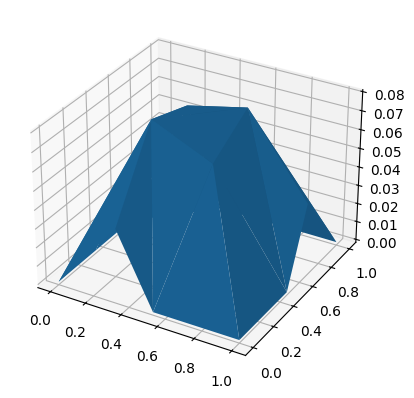

In [7]:
# Partie II : maillage mixte (triangles P1 + quadrangles Q1) et conditions de Neumann

def K_triangle(c):
    (x1,y1),(x2,y2),(x3,y3) = c
    alpha = (x2-x1)*(y3-y1) - (x3-x1)*(y2-y1)
    aire  = 0.5*abs(alpha)
    G = np.array([[y2-y3,x3-x2],[y3-y1,x1-x3],[y1-y2,x2-x1]]) / alpha
    return aire*(G@G.T), aire

def K_quad(c):
    (x1,y1),(x2,y2),_,(x4,y4) = c
    J     = np.array([[x2-x1,x4-x1],[y2-y1,y4-y1]])
    det_J = abs(np.linalg.det(J))
    G     = np.array([[-0.5,-0.5],[0.5,-0.5],[0.5,0.5],[-0.5,0.5]])
    return det_J*(G @ np.linalg.inv(J.T@J) @ G.T), det_J

def g_neumann(x, y):
    return 0.0

def assemblage_partie2(coordinates, elements3, elements4, dirichlet, neumann):
    n = len(coordinates)
    A = scps.lil_matrix((n, n))
    b = np.zeros(n)

    for elem in elements3:
        c = coordinates[elem]
        K, aire = K_triangle(c)
        b_loc = (aire/3.0) * f(*c.mean(axis=0))
        for i in range(3):
            b[elem[i]] += b_loc
            for j in range(3): A[elem[i],elem[j]] += K[i,j]

    for elem in elements4:
        c = coordinates[elem]
        K, det_J = K_quad(c)
        b_loc = (det_J/4.0) * f(*c.mean(axis=0))
        for i in range(4):
            b[elem[i]] += b_loc
            for j in range(4): A[elem[i],elem[j]] += K[i,j]

    for edge in neumann:
        p1,p2 = int(edge[0]),int(edge[1])
        L      = np.linalg.norm(coordinates[p2]-coordinates[p1])
        contrib = (L/2.0) * g_neumann(*(coordinates[p1]+coordinates[p2])/2.0)
        b[p1] += contrib; b[p2] += contrib
    
    for idx in np.array(dirichlet).flatten():
        A[idx,:] = 0.0; A[idx,idx] = 1.0
        b[idx] = u_d(*coordinates[idx])



    return A.tocsr(), b

A2, b2 = assemblage_partie2(ccs, e3, e4, dds, nns)
u2 = ssl.spsolve(A2, b2)
show(ccs, u2)

**Compléments  :  un nouveau terme dans l'EDP**

  n   noeuds     max(u)
----------------------------
   5      25   0.067108
  10     100   0.067825
  20     400   0.069359
  40    1600   0.069702
  60    3600   0.069762
 140   19600   0.069800


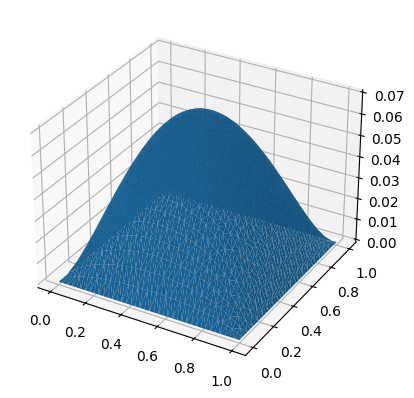

In [8]:
# ============================================================
#  -Delta u + c0*u = f
# Sur le PREMIER maillage (triangulaire pur, maillage(n))
# ============================================================

c0 = 1.0  

# --- Matrice de masse locale triangle ---
# M_ij = aire/6 si i=j,  aire/12 si i!=j
def M_masse_triangle(aire):
    return (aire / 12.0) * np.array([[2, 1, 1],
                                     [1, 2, 1],
                                     [1, 1, 2]])

# --- Assemblage triangles + Dirichlet homogene ---
def assemblage_tri_avec_masse(coordinates, elements3, dirichlet, c0):
    n_nodes = len(coordinates)
    A = scps.lil_matrix((n_nodes, n_nodes))
    b = np.zeros(n_nodes)

    for elem in elements3:
        x1,y1 = coordinates[elem[0]]
        x2,y2 = coordinates[elem[1]]
        x3,y3 = coordinates[elem[2]]

        # 1) alpha et aire
        alpha = (x2-x1)*(y3-y1) - (x3-x1)*(y2-y1)
        aire  = 0.5 * abs(alpha)

        # 2) Matrice de raideur locale K (identique Partie I)
        b_vec = [y2-y3, y3-y1, y1-y2]
        c_vec = [x3-x2, x1-x3, x2-x1]
        G     = np.column_stack((b_vec, c_vec)) / alpha
        K_loc = aire * (G @ G.T)

        # 3) Matrice de masse locale M 
        M_loc = M_masse_triangle(aire)

        # 4) Matrice locale totale = raideur + c0 * masse
        A_loc = K_loc + c0 * M_loc

        # 5) Second membre (quadrature )
        xG, yG = (x1+x2+x3)/3.0, (y1+y2+y3)/3.0
        b_loc  = (aire / 3.0) * f(xG, yG)

        # 6) Assemblage global
        for i in range(3):
            b[elem[i]] += b_loc
            for j in range(3):
                A[elem[i], elem[j]] += A_loc[i, j]

    # 7) Dirichlet homogene : u=0 sur tout le bord
    for idx in dirichlet.flatten():
        A[idx, :] = 0.0
        A[idx, idx] = 1.0
        b[idx] = 0.0

    return A.tocsr(), b


# --- Test a taille variable ---
print('  n   noeuds     max(u)')
print('-' * 28)
for n in [5, 10, 20, 40, 60, 140]:
    coords_n, elems_n, dir_n, _ = maillage(n)
    An, bn = assemblage_tri_avec_masse(coords_n, elems_n, dir_n, c0=c0)
    un = ssl.spsolve(An, bn)
    print(f'{n:>4}  {len(coords_n):>6}   {un.max():.6f}')

# --- Affichage pour n=40 ---
coords_40, elems_40, dir_40, _ = maillage(40)
A40, b40 = assemblage_tri_avec_masse(coords_40, elems_40, dir_40, c0=c0)
u40 = ssl.spsolve(A40, b40)
show(coords_40, u40)


 Convergence observee : max(u) -> ~0.0698 quand n augmente.
 Solution positive, nulle sur le bord (Dirichlet homogene).


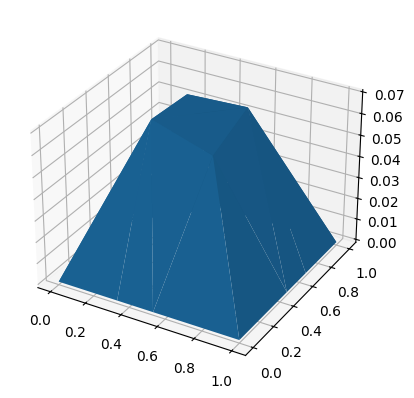

min/max : 0.0 0.06955361444807215


In [9]:
# ============================================================
# Section 2.2 : -Delta u + c0*u = f sur maillage mixte
# ============================================================

c0 = 1.0

# --- Etape 1 : maillage tout Dirichlet ---
dds_mod = np.unique(np.concatenate([dds, nns.flatten()]))
nns_mod = np.empty((0, 2), dtype=int)

# --- Etapes 2 & 3 : K_triangle et K_quad deja definis en Partie II ---

# --- Etape 4 : matrice de masse locale triangle ---
def M_masse_tri(aire):
    return (aire / 12.0) * np.array([[2,1,1],[1,2,1],[1,1,2]])

# --- Etape 5 : matrice de masse locale quadrangle ---
M_ref_quad = (1.0/36.0) * np.array([[4,2,1,2],[2,4,2,1],[1,2,4,2],[2,1,2,4]])
def M_masse_quad(det_J):
    return det_J * M_ref_quad

# --- Etapes 6 & 7 : assemblage A et b, Dirichlet homogene ---
def assemblage_22(coordinates, elements3, elements4, dirichlet, c0):
    n = len(coordinates)
    A = scps.lil_matrix((n, n))
    b = np.zeros(n)

    for elem in elements3:
        c = coordinates[elem]
        K, aire = K_triangle(c)
        A_loc = K + c0 * M_masse_tri(aire)
        b_loc = (aire / 3.0) * f(*c.mean(axis=0))
        for i in range(3):
            b[elem[i]] += b_loc
            for j in range(3): A[elem[i], elem[j]] += A_loc[i, j]

    for elem in elements4:
        c = coordinates[elem]
        K, det_J = K_quad(c)
        A_loc = K + c0 * M_masse_quad(det_J)
        b_loc = (det_J / 4.0) * f(*c.mean(axis=0))
        for i in range(4):
            b[elem[i]] += b_loc
            for j in range(4): A[elem[i], elem[j]] += A_loc[i, j]

    for idx in dirichlet:
        A[idx, :] = 0.0; A[idx, idx] = 1.0; b[idx] = 0.0

    return A.tocsr(), b

# --- Etape 8 : validation ---
A_22, b_22 = assemblage_22(ccs, e3, e4, dds_mod, c0)
u_22 = ssl.spsolve(A_22, b_22)
show(ccs, u_22)
print("min/max :", u_22.min(), u_22.max())
